# Neural Network from Scratch

This project aims to create an ANN and CNN from scratch and train and test it on the MNIST dataset of handwritten digits.

The neural networks are built by scratch without any industry grade libraries such as **Tensorflow** or **PyTorch**

The models follow similar pattern to Tensorflow, with a Dense, Activation, Flatten, MaxPooling and Conv2D layers in a Sequential Model.

Other activation functions, loss functions and optimizers can be viewed in the `./neural_network` directoy

In [1]:
import numpy as np
import pandas as pd
from neural_network import Sequential
from neural_network.layers import Dense, Activation, Conv2D, Flatten, MaxPool2D
from neural_network.activations import relu, relu_prime, softmax, softmax_prime, sigmoid, sigmoid_prime
from neural_network.losses import CategoricalCrossEntropy
from neural_network.optimizers import Adam, SGD
from preprocessing import train_test_split, plot_confusion_matrix

### Preprocessing and Load Data

In [2]:
def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

In [3]:
def load_data():
    df = pd.read_csv("datasets/nn/train.csv")
    data = np.array(df)
    m, n = data.shape
    np.random.shuffle(data)

    data_dev = data[0:1000].T
    Y_dev = data_dev[0]
    X_dev = data_dev[1:n]
    X_dev = X_dev / 255.

    data_train = data[1000:m].T
    Y_train = data_train[0]
    X_train = data_train[1:n]
    X_train = X_train / 255.
    
    return X_train, one_hot(Y_train), X_dev, one_hot(Y_dev)

### ANN

In [4]:
print("Training ANN...")
X_train, Y_train, X_dev, Y_dev = load_data()

model = Sequential([
    Dense(784, 128),
    Activation(relu, relu_prime),
    Dense(128, 64),
    Activation(relu, relu_prime),
    Dense(64, 10),
    Activation(softmax, lambda x: 1)
])

model.compile(loss=CategoricalCrossEntropy(), optimizer=Adam(learning_rate=0.001))
model.train(
    X_train, Y_train, 
    epochs=10, 

    batch_size=64, 
    x_val=X_dev, 
    y_val=Y_dev, 
    save_path='checkpoint_model.pkl')

Training ANN...
Model weights saved to checkpoint_model.pkl
Epoch 1/10, loss=0.5570, val_acc=0.9080 (Best till now)

Model weights saved to checkpoint_model.pkl
Epoch 2/10, loss=0.2431, val_acc=0.9220 (Best till now)

Model weights saved to checkpoint_model.pkl
Epoch 3/10, loss=0.1661, val_acc=0.9550 (Best till now)

Model weights saved to checkpoint_model.pkl
Epoch 4/10, loss=0.1259, val_acc=0.9560 (Best till now)

Model weights saved to checkpoint_model.pkl
Epoch 5/10, loss=0.1008, val_acc=0.9590 (Best till now)

Model weights saved to checkpoint_model.pkl
Epoch 6/10, loss=0.0815, val_acc=0.9650 (Best till now)

Model weights saved to checkpoint_model.pkl
Epoch 7/10, loss=0.0666, val_acc=0.9660 (Best till now)

Model weights saved to checkpoint_model.pkl
Epoch 8/10, loss=0.0557, val_acc=0.9700 (Best till now)

Model weights saved to checkpoint_model.pkl
Epoch 9/10, loss=0.0455, val_acc=0.9720 (Best till now)

Epoch 10/10, loss=0.0366, val_acc=0.9630


In [5]:
# Test ANN
model.load_weights('checkpoint_model.pkl')
predictions = model.predict(X_dev)
accuracy = np.sum(np.argmax(predictions, axis=0) == np.argmax(Y_dev, axis=0)) / Y_dev.shape[1]
print(f"ANN Dev Accuracy: {accuracy}")

Model weights loaded from checkpoint_model.pkl
ANN Dev Accuracy: 0.972


ANN Final Evaluation:
  Accuracy: 0.9720
  Precision (Macro): 0.9709
  Recall (Macro): 0.9722

Displaying ANN Confusion Matrix...


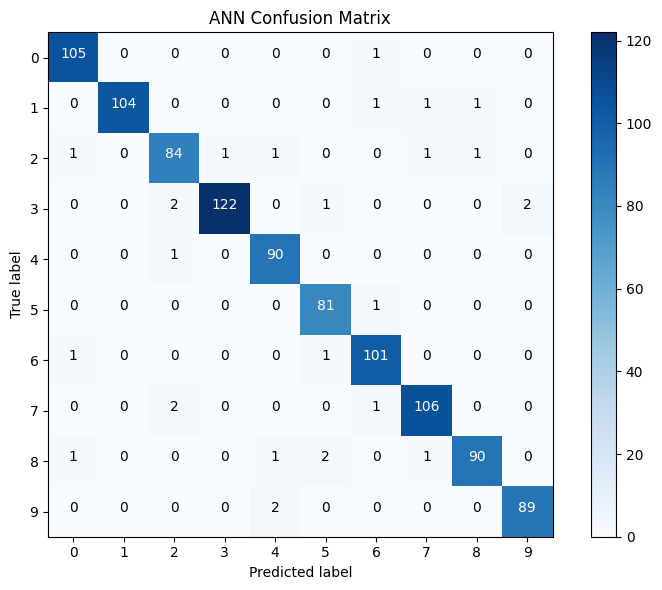

In [6]:
print("ANN Final Evaluation:")
metrics = model.get_metrics(X_dev, Y_dev)
for k, v in metrics.items():
    if k != "Confusion Matrix":
        print(f"  {k}: {v:.4f}")

print("\nDisplaying ANN Confusion Matrix...")
plot_confusion_matrix(np.argmax(Y_dev, axis=0), np.argmax(model.predict(X_dev), axis=0), title='ANN Confusion Matrix')

### CNN

CNN uses only a small subset of training and validation data due to the CNN being limited to CPU since only numpy is being used.

In [7]:
print("Training CNN...")
X_train, Y_train, X_dev, Y_dev = load_data()

# Reshape for CNN: (samples, depth, height, width)
X_train_cnn = X_train.T.reshape(-1, 1, 28, 28)
X_dev_cnn = X_dev.T.reshape(-1, 1, 28, 28)

# Tiny subset for speed
train_size, val_size = 500, 100
X_train_small = X_train_cnn[:train_size]
Y_train_small = Y_train[:, :train_size]
X_dev_small = X_dev_cnn[:val_size]
Y_dev_small = Y_dev[:, :val_size]

model = Sequential([
    Conv2D((1, 28, 28), kernel_size=3, depth=4),
    Activation(relu, relu_prime),
    MaxPool2D(pool_size=2),
    Flatten(),
    Dense(4 * 13 * 13, 10),
    Activation(softmax, lambda x: 1)
])

model.compile(loss=CategoricalCrossEntropy(), optimizer=Adam(learning_rate=0.001))
model.train(
    X_train_small, Y_train_small, 
    epochs=5, 
    batch_size=10, 
    x_val=X_dev_small, 
    y_val=Y_dev_small,
    save_path='cnn_checkpoint.pkl'
)

Training CNN...
Model weights saved to cnn_checkpoint.pkl
Epoch 1/5, loss=2.2097, val_acc=0.4600 (Best till now)

Model weights saved to cnn_checkpoint.pkl
Epoch 2/5, loss=1.7179, val_acc=0.7200 (Best till now)

Model weights saved to cnn_checkpoint.pkl
Epoch 3/5, loss=1.0880, val_acc=0.8200 (Best till now)

Epoch 4/5, loss=0.7758, val_acc=0.8100
Model weights saved to cnn_checkpoint.pkl
Epoch 5/5, loss=0.6089, val_acc=0.8300 (Best till now)



In [8]:
# Test CNN
model.load_weights('cnn_checkpoint.pkl')
print("\nCNN Final Evaluation (Subset):")
metrics = model.get_metrics(X_dev_small, Y_dev_small)
for k, v in metrics.items():
    if k != "Confusion Matrix":
        print(f"  {k}: {v:.4f}")


Model weights loaded from cnn_checkpoint.pkl

CNN Final Evaluation (Subset):
  Accuracy: 0.8300
  Precision (Macro): 0.8284
  Recall (Macro): 0.8326
